In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("insurance.csv")

In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
print("Numerical Features:")
print(df.select_dtypes(include=['int64','float64']).columns.tolist())

print("\nCategorical Features:")
print(df.select_dtypes(include=['object']).columns.tolist())

print("\nTarget Variable:")
print("charges")

Numerical Features:
['age', 'bmi', 'children', 'charges']

Categorical Features:
['sex', 'smoker', 'region']

Target Variable:
charges


In [5]:
print(df.isnull().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [6]:
encoder = LabelEncoder()

df["sex"] = encoder.fit_transform(df["sex"])
df["smoker"] = encoder.fit_transform(df["smoker"])
df["region"] = encoder.fit_transform(df["region"])

In [7]:
X = df.drop("charges", axis=1)
y = df["charges"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [10]:
y_pred = model.predict(X_test)

In [11]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 4186.508898366435


In [12]:
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 33635210.431178406


In [13]:
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.7833463107364539


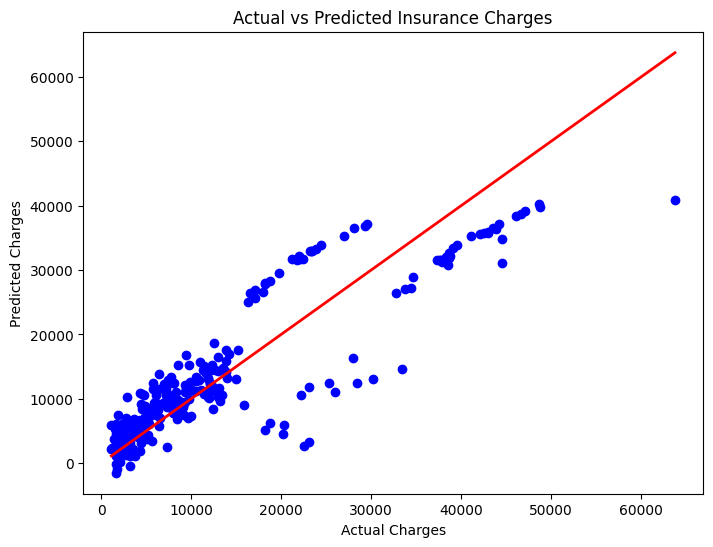

In [14]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, color="blue")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Insurance Charges")

plt.show()